In [2]:
!pip install xgboost
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

In [3]:
train_df = pd.read_csv('train_processed.csv')
val_df = pd.read_csv('val_processed.csv')
test_df = pd.read_csv('test_processed.csv')
w_train = pd.read_csv('w_train.csv').squeeze()
w_val = pd.read_csv('w_val.csv').squeeze()
w_test = pd.read_csv('w_test.csv').squeeze()

X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_val = val_df.drop(columns=['label'])
y_val = val_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

In [5]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                     eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train, sample_weight=w_train)

y_prob_xgb = xgb.predict_proba(X_val)[:, 1]

for thresh in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45]:
    y_pred = (y_prob_xgb >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.2: F1=0.1168
Threshold 0.25: F1=0.1168
Threshold 0.3: F1=0.1168
Threshold 0.35: F1=0.1168
Threshold 0.4: F1=0.1168
Threshold 0.45: F1=0.1168


In [6]:
print(y_prob_xgb[:20])
print(y_prob_xgb.min(), y_prob_xgb.max())

[0.5078243 0.5078243 0.5078243 0.5078243 0.5078243 0.5078243 0.5078243
 0.5078243 0.5078243 0.5078243 0.5078243 0.5078243 0.5078243 0.5078243
 0.5078243 0.5078243 0.5078243 0.5078243 0.5078243 0.5078243]
0.5078243 0.5078243


In [7]:
print(X_train.dtypes)
print(X_train.isnull().sum())

age                                           float64
class of worker                                 int64
education                                       int64
marital stat                                    int64
major occupation code                         float64
race                                            int64
sex                                             int64
full or part time employment stat             float64
capital gains                                   int64
capital losses                                  int64
dividends from stocks                           int64
tax filer stat                                  int64
detailed household summary in household         int64
num persons worked for employer                 int64
citizenship                                   float64
own business or self employed                   int64
fill inc questionnaire for veteran's admin      int64
veterans benefits                               int64
weeks worked in year        

In [8]:
print(f"Class 0 count: {len(y_train[y_train==0])}")
print(f"Class 1 count: {len(y_train[y_train==1])}")
print(f"scale_pos_weight: {scale_pos_weight}")
print(y_train.value_counts())

Class 0 count: 130999
Class 1 count: 8667
scale_pos_weight: 15.11468789661936
label
0    130999
1      8667
Name: count, dtype: int64


In [9]:
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                     eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)  # no sample_weight

y_prob_xgb = xgb.predict_proba(X_val)[:, 1]
print(y_prob_xgb.min(), y_prob_xgb.max())

1.05854205e-07 0.99451244


In [10]:
for thresh in [0.5, 0.6, 0.7, 0.8, 0.82, 0.85, 0.9]:
    y_pred = (y_prob_xgb >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.5: F1=0.4112
Threshold 0.6: F1=0.4550
Threshold 0.7: F1=0.4975
Threshold 0.8: F1=0.5308
Threshold 0.82: F1=0.5367
Threshold 0.85: F1=0.5396
Threshold 0.9: F1=0.5176


In [11]:
for thresh in [0.83, 0.84, 0.85, 0.86, 0.87, 0.88]:
    y_pred = (y_prob_xgb >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.83: F1=0.5414
Threshold 0.84: F1=0.5409
Threshold 0.85: F1=0.5396
Threshold 0.86: F1=0.5423
Threshold 0.87: F1=0.5443
Threshold 0.88: F1=0.5393


              precision    recall  f1-score   support

           0       0.97      0.97      0.97     28071
           1       0.54      0.54      0.54      1857

    accuracy                           0.94     29928
   macro avg       0.76      0.76      0.76     29928
weighted avg       0.94      0.94      0.94     29928

ROC-AUC: 0.9340068466668112

Of every 100 flagged: 54 are genuine high earners
Model catches 54% of all actual high earners


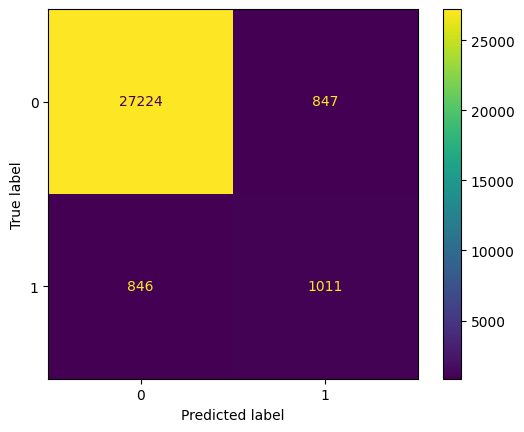

In [12]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_xgb_final = (y_prob_xgb >= 0.87).astype(int)
print(classification_report(y_val, y_pred_xgb_final))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_xgb))

cm = confusion_matrix(y_val, y_pred_xgb_final)
ConfusionMatrixDisplay(cm).plot()

tn, fp, fn, tp = cm.ravel()
print(f"\nOf every 100 flagged: {tp/(tp+fp)*100:.0f} are genuine high earners")
print(f"Model catches {tp/(tp+fn)*100:.0f}% of all actual high earners")

In [13]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_tuned = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                  eval_metric='logloss', verbosity=0),
    params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

xgb_tuned.fit(X_train, y_train)
print(f"Best params: {xgb_tuned.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [14]:
best_xgb = xgb_tuned.best_estimator_

y_prob_xgb_tuned = best_xgb.predict_proba(X_val)[:, 1]

for thresh in [0.83, 0.85, 0.87, 0.88, 0.90]:
    y_pred = (y_prob_xgb_tuned >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.83: F1=0.5340
Threshold 0.85: F1=0.5392
Threshold 0.87: F1=0.5341
Threshold 0.88: F1=0.5334
Threshold 0.9: F1=0.5162


              precision    recall  f1-score   support

           0       0.97      0.97      0.97     28071
           1       0.52      0.56      0.54      1857

    accuracy                           0.94     29928
   macro avg       0.74      0.76      0.75     29928
weighted avg       0.94      0.94      0.94     29928

ROC-AUC: 0.9293455377123094

Of every 100 flagged: 52 are genuine high earners
Model catches 56% of all actual high earners


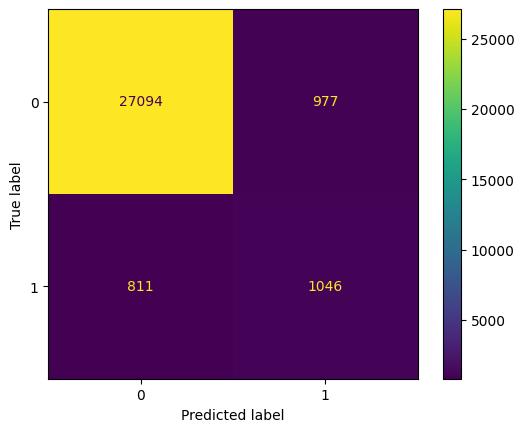

In [17]:
y_pred_xgb_tuned_final = (y_prob_xgb_tuned >= 0.85).astype(int)
print(classification_report(y_val, y_pred_xgb_tuned_final))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_xgb_tuned))

cm = confusion_matrix(y_val, y_pred_xgb_tuned_final)
ConfusionMatrixDisplay(cm).plot()

tn, fp, fn, tp = cm.ravel()
print(f"\nOf every 100 flagged: {tp/(tp+fp)*100:.0f} are genuine high earners")
print(f"Model catches {tp/(tp+fn)*100:.0f}% of all actual high earners")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = (y_prob >= 0.82).astype(int)
cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
print(confusion_matrix(y_val, y_pred_best))